In [17]:
import argparse
import logging
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import random
import os

from app.test import test
from definitions import OUT_DIR
from src.agent.encoder import FeaturesExtractor
from src.app.drl_scheduler import DrlScheduler
from src.env.env import NetEnv, TrainingNetEnv
from src.lib.log_config import log_config
from src.lib.timing_decorator import timing_decorator
from src.network.net import FlowGenerator, generate_graph, Network

from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv

TOPO = 'CEV'
NUM_ENVS = 1
NUM_FLOWS = 10
jitters = [[0.1, 0.2, 0.3]]  
list_jitters = np.array(jitters)
link_rate = 100

DRL_ALG = 'MaskablePPO'

MONITOR_ROOT_DIR = os.path.join(OUT_DIR, "monitor")


def get_best_model_path():
    return os.path.join(OUT_DIR, f"best_model_{TOPO}_{DRL_ALG}")


def make_env(num_flows, rank: int, topo: str, list_jitters, training: bool = True, link_rate: int = 100):
    def _init():
        graph = generate_graph(topo, link_rate)

        assert list_jitters.ndim == 2
        list_flow_generators = []
        for jitters in list_jitters:
            flow_generator = FlowGenerator(graph, jitters=jitters)
            list_flow_generators.append(flow_generator)

        if training:
            env = TrainingNetEnv(graph, random.choice(list_flow_generators), num_flows, 0.2, 0.1)
        else:
            flows = random.choice(list_flow_generators)(num_flows)
            env = NetEnv(Network(graph, flows))

        # Wrap the environment with Monitor
        env = Monitor(env, os.path.join(MONITOR_DIR, f'{"train" if training else "eval"}_{rank}'))

        return env

    return _init


@timing_decorator(logging.info)
def train(topo: str, num_time_steps, jitters, num_flows=NUM_FLOWS, pre_trained_model=None, link_rate=100):
    os.makedirs(OUT_DIR, exist_ok=True)

    n_envs = NUM_ENVS  # Number of environments to create
    env = SubprocVecEnv([
        make_env(num_flows, i, topo, jitters, link_rate=link_rate)
        for i in range(n_envs)
        ])

    if pre_trained_model is not None:
        model = DrlScheduler.SUPPORTING_ALG[DRL_ALG].load(pre_trained_model, env)
    else:
        policy_kwargs = dict(
            features_extractor_class=FeaturesExtractor,
        )

        if DRL_ALG == 'DQN':
            # limit the buffer size.
            model = DrlScheduler.SUPPORTING_ALG[DRL_ALG]("MultiInputPolicy", env, policy_kwargs=policy_kwargs, verbose=1,
                                                         buffer_size=500_000)
        else:
            model = DrlScheduler.SUPPORTING_ALG[DRL_ALG]("MultiInputPolicy", env, policy_kwargs=policy_kwargs, verbose=1)

    eval_env = SubprocVecEnv([
        make_env(num_flows, i, topo, jitters, training=False, link_rate=link_rate)
        for i in range(n_envs)
        ])
    callback = EvalCallback(eval_env, best_model_save_path=get_best_model_path(),
                            log_path=OUT_DIR, eval_freq=max(10000 // n_envs, 1))

    # logging.debug(model.policy)

    # Train the agent
    model.learn(total_timesteps=num_time_steps, callback=callback)

    logging.info("------Finish learning------")


def moving_average(values, window):
    """
    Smooth values by doing a moving average
    :param values: (numpy array)
    :param window: (int)
    :return: (numpy array)
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, "valid")


def plot_results(log_folder, title="Learning Curve"):
    """
    plot the results

    :param log_folder: (str) the save location of the results to plot
    :param title: (str) the title of the task to plot
    """
    x, y = ts2xy(load_results(log_folder), "timesteps")
    y = moving_average(y, window=50)
    # Truncate x
    x = x[len(x) - len(y):]

    fig = plt.figure(title)
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    plt.title(title + " Smoothed")
    plt.savefig(os.path.join(log_folder, "reward.png"))
    plt.show()


if __name__ == "__main__":
    # specify an existing model to train.
    parser = argparse.ArgumentParser()
    parser.add_argument('--time_steps', type=int, required=True)
    parser.add_argument('--num_flows', type=int, nargs='?', default=NUM_FLOWS)
    parser.add_argument('--debug', action='store_true')
    parser.add_argument('--num_envs', type=int, default=NUM_ENVS)
    parser.add_argument('--alg', type=str, default=None)
    parser.add_argument('--model', type=str, default=None)
    parser.add_argument('--topo', type=str, default="CEV")
    parser.add_argument('--link_rate', type=int, default=100)
    parser.add_argument('--jitters', type=str, nargs='+', required=True)
    args = parser.parse_args()

    if args.alg is not None:
        assert args.alg in DrlScheduler.SUPPORTING_ALG, ValueError(f"Unknown alg {args.alg}")
        DRL_ALG = args.alg

    if args.link_rate is not None:
        support_link_rates = [100, 1000]
        assert args.link_rate in support_link_rates, \
            f"Unknown link rate {args.link_rate}, which is not in supported link rates {support_link_rates}"

    list_jitters = []
    for jitters in args.jitters:
        jitters = [float(j) for j in jitters.split(",")]
        assert all(0 <= j <= 1 for j in jitters), ValueError(f"Jitters should be in range [0, 1]")
        list_jitters.append(jitters)
    list_jitters = np.array(list_jitters)

    TOPO = args.topo

    NUM_ENVS = args.num_envs

    log_config(os.path.join(OUT_DIR, f"train.log"), logging.DEBUG)

    logging.info(args)

    done = False
    i = 0
    MONITOR_DIR = None
    while not done:
        try:
            MONITOR_DIR = os.path.join(MONITOR_ROOT_DIR, str(i))
            os.makedirs(MONITOR_DIR, exist_ok=False)
            done = True
        except OSError:
            i += 1
            continue
    assert MONITOR_DIR is not None

    logging.info("start training...")
    train(args.topo, args.time_steps,
          list_jitters,
          num_flows=args.num_flows,
          pre_trained_model=args.model,
          link_rate=args.link_rate)

    # MONITOR_DIR = os.path.join(MONITOR_ROOT_DIR, str(1))
    plot_results(MONITOR_DIR)

    test(args.topo, args.num_flows, NUM_ENVS,
         os.path.join(get_best_model_path(), "best_model"), DRL_ALG, args.link_rate)


usage: ipykernel_launcher.py [-h] --time_steps TIME_STEPS
                             [--num_flows [NUM_FLOWS]] [--debug]
                             [--num_envs NUM_ENVS] [--alg ALG] [--model MODEL]
                             [--topo TOPO] [--link_rate LINK_RATE] --jitters
                             JITTERS [JITTERS ...]
ipykernel_launcher.py: error: the following arguments are required: --time_steps, --jitters


SystemExit: 2

In [19]:
from src.env.env import NetEnv
from src.network.net import generate_cev, generate_flows, Network

graph = generate_cev()
flows = generate_flows(graph, num_flows=10)
network = Network(graph, flows)

env = NetEnv(network)

In [21]:
from app.train import train

time_steps = 100000
num_flows = 5
topo = "CEV"
link_rate = 100
jitters = [[0.1, 0.2, 0.3]]  # This should match flow count
list_jitters = np.array(jitters)

train(topo, time_steps, list_jitters, num_flows=num_flows, link_rate=link_rate)

NameError: name 'c' is not defined

In [11]:
from stable_baselines3.common.monitor import Monitor

env = Monitor(env)


NameError: name 'env' is not defined

In [ ]:
from src.app.drl_scheduler import DrlScheduler

DRL_ALG = 'MaskablePPO'

In [36]:
from src.agent.encoder import FeaturesExtractor

policy_kwargs = dict(
    features_extractor_class=FeaturesExtractor,
)

model = DrlScheduler.SUPPORTING_ALG[DRL_ALG](
    "MultiInputPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [38]:
model.learn(total_timesteps=100_000)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 45       |
|    ep_rew_mean     | 41.3     |
| time/              |          |
|    fps             | 200      |
|    iterations      | 1        |
|    time_elapsed    | 10       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 45           |
|    ep_rew_mean          | 41.5         |
| time/                   |              |
|    fps                  | 137          |
|    iterations           | 2            |
|    time_elapsed         | 29           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0076365527 |
|    clip_fraction        | 0.0318       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.685       |
|    explained_variance   | -0.049       |
|    learning_r

In [40]:
model.save("my_trained_model")
 

In [42]:
obs, _ = env.reset()
done = False

while not done:
    action, _ = model.predict(obs)
    obs, reward, done, truncated, info = env.step(action)
    print("Reward:", reward)


Reward: 0.9921875
Reward: 0.9931875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9961875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 1.0011875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 1.0081875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.984375
Reward: 0.9475
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.875
Reward: 0.9921875
Reward: 1.0281875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 1.0411875
Reward: 0.96875
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.9921875
Reward: 1.02525
Reward: 0.9921875
Reward: 0.9921875
Reward: 0.875
Reward: 0.9921875
Reward: 0.9921875
Reward: 1.0731875
Reward: 0.9921875
Reward: 0.9375
Reward: 0.9921875
Reward: 0.69
Reward: 0.85


In [44]:
import os
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.monitor import Monitor

In [46]:
def moving_average(values, window):
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

In [5]:
def plot_results(log_folder, title="Learning Curve"):
    x, y = ts2xy(load_results(log_folder), "timesteps")
    y = moving_average(y, window=50)
    x = x[len(x) - len(y):]  # Align x with y after smoothing

    plt.figure(figsize=(10, 5))
    plt.plot(x, y)
    plt.xlabel("Number of Timesteps")
    plt.ylabel("Rewards")
    plt.title(title)
    plt.grid(True)
    plt.savefig(os.path.join(log_folder, "reward.png"))
    plt.show()

In [15]:
#!/usr/bin/env python
# coding: utf-8

# In[5]:

 
from src.network.net import Flow, Network
from src.env.env import NetEnv


def get_link_ids_from_path(graph, path, links_dict):
    link_ids = []
    for u, v in zip(path[:-1], path[1:]):
        for link_id, link in links_dict.items():
            if link.link_id[0] == u and link.link_id[1] == v:
                link_ids.append(link_id)
    return link_ids



def custom_graph():
    import networkx as nx
    G = nx.DiGraph()
    G.add_edge("A", "B", link_rate=100)
    G.add_edge("B", "C", link_rate=100)
    return G

def custom_flows(graph):
    temp_net = Network(graph, [])  # empty flows to generate links
    links_dict = temp_net.links_dict

    return [
        Flow(
            flow_id=0,
            src_id="A",
            dst_id="C",
            path=get_link_ids_from_path(graph, ["A", "B", "C"], links_dict),
            period=2000,
            payload=1000,
            e2e_delay=2000,
            jitter=10
        )
    ]




# In[ ]:






In [17]:
graph = custom_graph()
flows = custom_flows(graph)
network = Network(graph, flows)
env = NetEnv(network)


In [19]:
import matplotlib.pyplot as plt
import networkx as nx

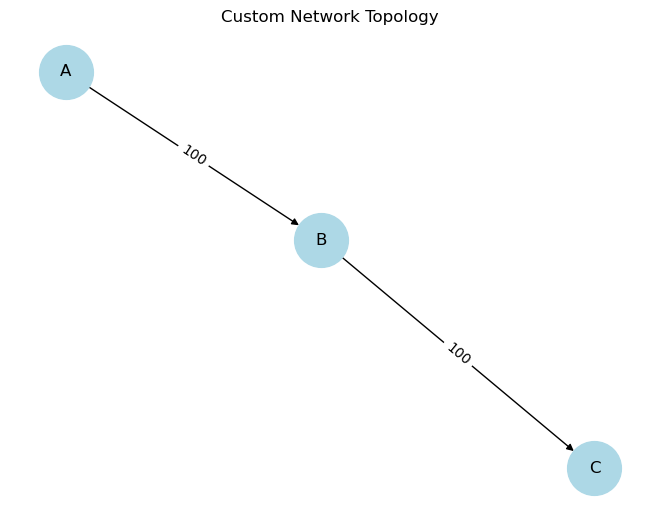

In [21]:

# Draw the graph
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=12, arrows=True)
edge_labels = nx.get_edge_attributes(graph, 'link_rate')
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)
plt.title("Custom Network Topology")
plt.show()


In [23]:
for flow in flows:
    print(flow)
    print("  Link path:")
    for link_id in flow.path:
        link = network.links_dict[link_id]
        print(f"    {link.link_id}")  # Will print e.g., ('A', 'B')
    print("-" * 30)


Flow 0 [A-->C] with period 2000, payload 1000B, e2e delay 2000us, jitter 10us
  Link path:
    ('A', 'B')
    ('B', 'C')
------------------------------


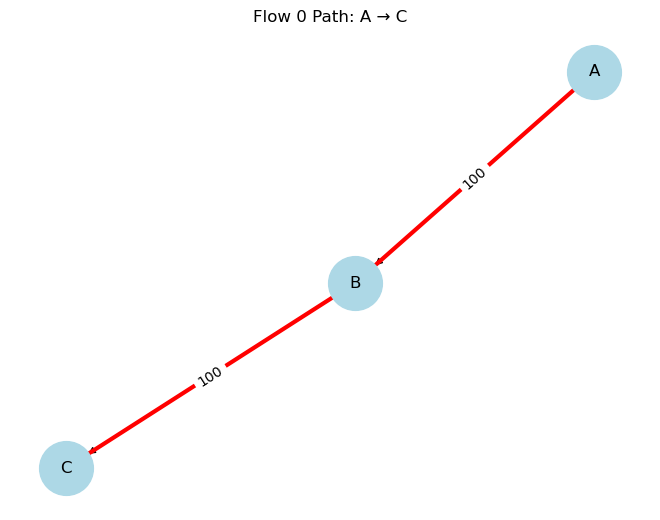

In [25]:
import matplotlib.pyplot as plt
import networkx as nx

def visualize_flow_path(graph, flow):
    pos = nx.spring_layout(graph, seed=42)  # fixed layout for consistent drawing

    # Extract path nodes from the flow
    path_nodes = []
    for link_id in flow.path:
        u, v = link_id  # assuming link_id is a tuple like ('A', 'B')
        path_nodes.append((u, v))

    # Draw base graph
    nx.draw(graph, pos, with_labels=True, node_color='lightblue', node_size=1500, font_size=12, arrows=True)

    # Draw all edges in light gray
    nx.draw_networkx_edges(graph, pos, edge_color='lightgray', width=2)

    # Highlight the flow path in red
    nx.draw_networkx_edges(graph, pos, edgelist=path_nodes, edge_color='red', width=3)

    # Add edge labels (link rates)
    edge_labels = nx.get_edge_attributes(graph, 'link_rate')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels)

    plt.title(f"Flow {flow.flow_id} Path: {flow.src_id} → {flow.dst_id}")
    plt.show()

# Example usage
flow = flows[0]  # pick a flow to visualize
visualize_flow_path(graph, flow)


In [27]:
def custom_graph():
    import networkx as nx
    G = nx.DiGraph()
    
    # Add more nodes and directed edges
    G.add_edge("A", "B", link_rate=100)
    G.add_edge("B", "C", link_rate=100)
    G.add_edge("C", "D", link_rate=100)
    G.add_edge("A", "E", link_rate=100)
    G.add_edge("E", "D", link_rate=100)
    G.add_edge("B", "E", link_rate=100)

    return G


Custom Scenario

In [47]:
from src.network.net import PERIOD_SET
print(PERIOD_SET)



[2000, 4000, 8000, 16000, 32000, 64000, 128000]


In [65]:
def custom_flows(graph):
    from src.network.net import Flow, Network

    temp_net = Network(graph, [])  # initialize links
    links_dict = temp_net.links_dict

    def get_link_ids_from_path(graph, path, links_dict):
        link_ids = []
        for u, v in zip(path[:-1], path[1:]):
            for link_id, link in links_dict.items():
                if link_id == (u, v):  # important!
                    link_ids.append(link_id)
        return link_ids

    return [
        Flow(0, "A", "D", get_link_ids_from_path(graph, ["A", "B", "C", "D"], links_dict), period=2000, payload=1000, jitter=10),
        Flow(1, "A", "D", get_link_ids_from_path(graph, ["A", "B", "E", "D"], links_dict), period=4000, payload=800, jitter=20),
        Flow(2, "B", "D", get_link_ids_from_path(graph, ["B", "E", "D"], links_dict), period=4000, payload=900, jitter=15)
    ]


In [67]:
graph = custom_graph()
flows = custom_flows(graph)
network = Network(graph, flows)
env = NetEnv(network)

obs, _ = env.reset()  # reset environment to get the first observation



In [73]:
def visualize_flows(graph, flows, links_dict):
    pos = nx.spring_layout(graph)  # Use consistent layout
    plt.figure(figsize=(10, 7))
    
    # Draw the basic graph (nodes and edges)
    nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(graph, pos, font_size=12, font_weight='bold')
    nx.draw_networkx_edges(graph, pos, edge_color='gray', arrows=True)

    # Colors for different flows
    colors = ['red', 'green', 'blue', 'purple', 'orange', 'brown', 'cyan', 'magenta']

    # Helper: link ID to (src, dst)
    link_map = {link_id: link.link_id for link_id, link in links_dict.items()}

    for i, flow in enumerate(flows):
        flow_color = colors[i % len(colors)]
        path_links = flow.path
        path_edges = [link_map[link_id] for link_id in path_links]

        # Draw the flow's path
        nx.draw_networkx_edges(
            graph,
            pos,
            edgelist=path_edges,
            edge_color=flow_color,
            width=2.5,
            arrows=True
        )

        # Annotate flow ID at source or destination
        src_pos = pos[flow.src_id]
        plt.text(
            src_pos[0], src_pos[1] + 0.1,  # Slight offset from node
            f"Flow {flow.flow_id}",
            fontsize=10,
            fontweight='bold',
            color=flow_color,
            bbox=dict(facecolor='white', edgecolor=flow_color, boxstyle='round,pad=0.2')
        )
        # inside the for-loop in visualize_flows
        dst_pos = pos[flow.dst_id]
        plt.text(
            dst_pos[0], dst_pos[1] - 0.1,  # Slight offset from node
            f"Flow {flow.flow_id}",
            fontsize=10,
            fontweight='bold',
            color=flow_color,
            bbox=dict(facecolor='white', edgecolor=flow_color, boxstyle='round,pad=0.2')
            )


    plt.title("Flow Paths with Color-Coded Labels")
    plt.axis("off")
    plt.show()


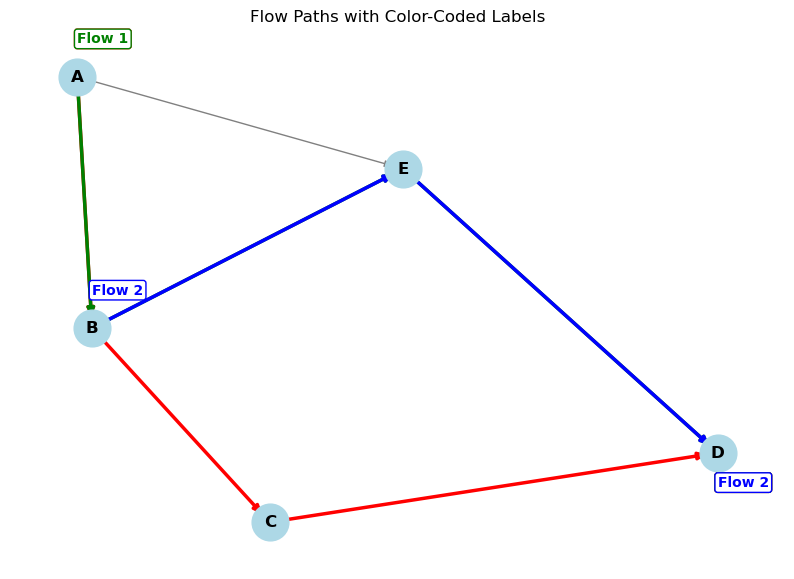

In [75]:
visualize_flows(graph, flows, network.links_dict)

Manually simulate the environment

In [80]:
graph = custom_graph()
flows = custom_flows(graph)
network = Network(graph, flows)
env = NetEnv(network)


In [88]:
obs, info = env.reset()


In [90]:
import numpy as np

In [94]:
obs, _ = env.reset()
done = False

while not done:
    # Get the valid actions mask from the environment
    mask = env.action_masks()
    available_actions = np.where(mask)[0]  # Convert mask to action indices

    print("Available actions:", available_actions)

    # Choose an action (e.g., first valid one)
    action = available_actions[0]  # or manually choose
    obs, reward, done, _, info = env.step(action)

    print("Reward:", reward)
    print("Info:", info)



Available actions: [0 1]
Reward: 0.69
Info: {'success': False}
Available actions: [0 1]
Reward: 0.69
Info: {'success': False}
Available actions: [1]
Reward: 1.003298611111111
Info: {'success': False}
Available actions: [0 1]
Reward: 0.38
Info: {'success': False}
Available actions: [0 1]
Reward: 0.38
Info: {'success': False}
Available actions: [1]
Reward: 1.0366319444444445
Info: {'success': False}
Available actions: [0 1]
Reward: 0.69
Info: {'success': False}
Available actions: [1]
Reward: 1.0921875
Info: {'success': True, 'ScheduleRes': defaultdict(<class 'list'>, {Link('A', 'B'): [(<src.network.net.Flow object at 0x0000020D06FEA240>, Operation(0, None, 190)(0, 124)), (<src.network.net.Flow object at 0x0000020D06FE99D0>, Operation(190, None, 396)(190, 314))], Link('B', 'C'): [(<src.network.net.Flow object at 0x0000020D06FE99D0>, Operation(274, None, 609)(274, 527))], Link('B', 'E'): [(<src.network.net.Flow object at 0x0000020D06FEA240>, Operation(68, None, 387)(68, 321)), (<src.networ

Example of training

In [230]:
!pip install tensorboard


   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   --------- ------------------------------ 1.3/5.5 MB 8.4 MB/s eta 0:00:01
   ------------------------ --------------- 3.4/5.5 MB 9.1 MB/s eta 0:00:01
   -------------------------------------- - 5.2/5.5 MB 8.9 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 8.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   --------- ------------------------------ 1.0/4.3 MB 7.2 MB/s eta 0:00:01
   ---------------------------------- ----- 3.7/4.3 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 8.6 MB/s eta 0:00:00


In [234]:
tensorboard_log=os.path.join(OUT_DIR, "tensorboard")


In [468]:
import os
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback

from src.env.env import TrainingNetEnv
from src.network.net import generate_graph, FlowGenerator
from src.agent.encoder import FeaturesExtractor
from src.app.drl_scheduler import DrlScheduler

# Define parameters
topo = "CEV"  # or your custom topo if you've defined one
link_rate = 100
num_flows = 10
time_steps = 100000
jitters = [[0.1, 0.2, 0.3]]  
list_jitters = np.array(jitters)

# Create OUT_DIR
OUT_DIR = "./out"
MONITOR_DIR = os.path.join(OUT_DIR, "monitor")
os.makedirs(MONITOR_DIR, exist_ok=True)

# Create single-environment training using DummyVecEnv
def make_env():
    graph = generate_graph(topo, link_rate)
    flow_generator = FlowGenerator(graph, jitters=jitters[0])
    env = TrainingNetEnv(graph, flow_generator, num_flows=num_flows)
    env = Monitor(env, MONITOR_DIR)
    return env

# Vectorized env wrapper (single env for Jupyter)
env = DummyVecEnv([make_env])

# Policy arguments for GNN encoder
policy_kwargs = dict(features_extractor_class=FeaturesExtractor)

# Create the PPO model
model = PPO(
    "MultiInputPolicy", 
    env, 
    policy_kwargs=policy_kwargs, 
    verbose=1
)


# Optional: Evaluation environment
eval_env = DummyVecEnv([make_env])
callback = EvalCallback(eval_env, best_model_save_path=os.path.join(OUT_DIR, "best_model"),
                        log_path=OUT_DIR, eval_freq=1000)

# Train the agent
model.learn(total_timesteps=time_steps, callback=callback)

# Save model
model.save(os.path.join(OUT_DIR, "my_trained_model"))


INFO:src.env.env.15164:Start training with 2 flows.
INFO:src.env.env.15164:Start training with 2 flows.
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)


Using cpu device


INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 3
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Chan

Eval num_timesteps=1000, episode_reward=7.92 +/- 0.03
Episode length: 8.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 8        |
|    mean_reward     | 7.92     |
| time/              |          |
|    total_timesteps | 1000     |
---------------------------------


INFO:src.env.env.15164:passed the job! (2)


...

Eval num_timesteps=99000, episode_reward=36.04 +/- 0.17
Episode length: 37.00 +/- 0.00
----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 37         |
|    mean_reward          | 36         |
| time/                   |            |
|    total_timesteps      | 99000      |
| train/                  |            |
|    approx_kl            | 0.00702597 |
|    clip_fraction        | 0.0582     |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.385     |
|    explained_variance   | 0.578      |
|    learning_rate        | 0.0003     |
|    loss                 | 17.6       |
|    n_updates            | 480        |
|    policy_gradient_loss | 0.00192    |
|    value_loss           | 35.3       |
----------------------------------------


INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job!

Eval num_timesteps=100000, episode_reward=35.81 +/- 0.17
Episode length: 37.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 37       |
|    mean_reward     | 35.8     |
| time/              |          |
|    total_timesteps | 100000   |
---------------------------------


INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 41.7     |
|    ep_rew_mean     | 40.6     |
| time/              |          |
|    fps             | 97       |
|    iterations      | 49       |
|    time_elapsed    | 1032     |
|    total_timesteps | 100352   |
---------------------------------


In [496]:
import matplotlib.pyplot as plt
from stable_baselines3.common.results_plotter import load_results, ts2xy

def moving_average(values, window):
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

def plot_results(log_folder, title="Learning Curve"):
    x, y = ts2xy(load_results(log_folder), "timesteps")
    if len(y) < 50:
        print("⚠️ Not enough data to smooth. Showing raw rewards.")
        plt.plot(x, y)
    else:
        y_smooth = moving_average(y, window=50)
        x = x[len(x) - len(y_smooth):]
        plt.plot(x, y_smooth)

    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_results(MONITOR_DIR, title="Training Reward Over Time")


KeyError: 't'

In [474]:
from stable_baselines3 import PPO
import numpy as np

# Load trained model
model = PPO.load("out/my_trained_model")

# Create environment (must match training setup!)
#env = make_env(num_flows, 0, "CUSTOM", list_jitters, training=False, link_rate=100)()
obs = env.reset()

done = False
actions_taken = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    actions_taken.append(action)

    obs, reward, done, info = env.step(action)


print("Actions taken in this episode:")
print(actions_taken)


INFO:src.env.env.15164:passed the job! (9)


Actions taken in this episode:
[array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([1], dtype=int64), array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=i

In [476]:
actions_clean = [int(a[0]) for a in actions_taken]
print(actions_clean)

[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0]


In [478]:
actions_with_flow = []

obs = env.reset()
done = False

while not done:
    current_flow_id = env.envs[0].env.current_flow().flow_id
    current_link_id = env.envs[0].env.current_link().link_id

    action, _ = model.predict(obs)
    actions_with_flow.append((current_flow_id, current_link_id, action))

    obs, reward, done, info = env.step(action)


# Show Results
for flow_id, link_id, action in actions_with_flow:
    print(f"Flow {flow_id}, Link {link_id}, Action: {'Gating' if action == 1 else 'No Gating'}")


INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10


Flow F2353, Link ('CM2CB', 'SW42'), Action: Gating
Flow F2353, Link ('SW42', 'SW52'), Action: No Gating
Flow F2353, Link ('SW52', 'SM2CA'), Action: No Gating
Flow F2348, Link ('DU3', 'SW11'), Action: Gating
Flow F2348, Link ('SW11', 'SW21'), Action: No Gating
Flow F2348, Link ('SW21', 'CMRIU1'), Action: Gating
Flow F2349, Link ('MIMU1', 'SW13'), Action: No Gating
Flow F2349, Link ('SW13', 'SW22'), Action: Gating
Flow F2349, Link ('SW22', 'SW32'), Action: Gating
Flow F2349, Link ('SW32', 'SW42'), Action: Gating
Flow F2349, Link ('SW42', 'CM2CA'), Action: No Gating
Flow F2350, Link ('SM2CB', 'SW52'), Action: No Gating
Flow F2350, Link ('SW52', 'SW42'), Action: No Gating
Flow F2350, Link ('SW42', 'SW32'), Action: No Gating
Flow F2350, Link ('SW32', 'SW22'), Action: No Gating
Flow F2350, Link ('SW22', 'BFCU'), Action: No Gating
Flow F2351, Link ('StarTr2', 'SW13'), Action: No Gating
Flow F2351, Link ('SW13', 'SW21'), Action: No Gating
Flow F2351, Link ('SW21', 'SW12'), Action: Gating
Flow 

In [480]:
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

from src.env.env import NetEnv
from src.network.net import generate_graph, generate_flows, Network

# --- Load environment ---
topo = "CEV"         # or "CUSTOM" if you're using your own
link_rate = 100
num_flows = 10

graph = generate_graph(topo, link_rate)
flows = generate_flows(graph, num_flows)
network = Network(graph, flows)
env = NetEnv(network)

# Wrap environment for compatibility with SB3
vec_env = DummyVecEnv([lambda: env])

# --- Load trained PPO model ---
model = PPO.load("out/my_trained_model")  # Adjust path if needed

# --- Run one testing episode ---
obs = vec_env.reset()
done = False
actions_taken = []

# Unwrap the environment to access flow and link info
env_instance = vec_env.envs[0]

print("=== Testing Agent ===")
while not done:
    # Predict action
    action, _ = model.predict(obs, deterministic=True)
    
    # Optional: get current flow/link for context
    current_flow = env_instance.current_flow()
    current_link = env_instance.current_link()

    # Step through environment
    obs, reward, done, info = vec_env.step(action)

    # Save or print action
    actions_taken.append((current_flow.flow_id, current_link.link_id, int(action[0])))
    print(f"Flow {current_flow.flow_id}, Link {current_link.link_id}, Action: {'Gating' if action[0]==1 else 'No Gating'}, Reward: {reward[0]}")

# --- Show all actions taken ---
print("\n=== Summary of Actions Taken ===")
for flow_id, link_id, action in actions_taken:
    print(f"Flow {flow_id}, Link {link_id}, Action: {'Gating' if action == 1 else 'No Gating'}")


=== Testing Agent ===
Flow F7, Link ('SMRIU2', 'SW6'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW6', 'SW31'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW31', 'SW8'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW8', 'SW52'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW52', 'SM2CB'), Action: Gating, Reward: 0.9931874871253967
Flow F1, Link ('CM1CB', 'SW41'), Action: No Gating, Reward: 0.9903125166893005
Flow F1, Link ('SW41', 'SW31'), Action: No Gating, Reward: 0.9903125166893005
Flow F1, Link ('SW31', 'SW21'), Action: No Gating, Reward: 0.9903125166893005
Flow F1, Link ('SW21', 'SW11'), Action: No Gating, Reward: 0.9903125166893005
Flow F1, Link ('SW11', 'DU2'), Action: No Gating, Reward: 0.9943125247955322
Flow F8, Link ('MIMU2', 'SW13'), Action: No Gating, Reward: 0.9806249737739563
Flow F8, Link ('SW13', 'SW22'), Action: No Gating, Reward: 0.9806249737739563
Flow F8, Link ('SW22', 'SW32'), Action: No Gating, Reward: 0.9806249737739563
Flow F8, Link (

In [365]:
env_instance = vec_env.envs[0]

# Extract flows from the environment
flow_data = env_instance.flows  

# Collect flow info
flow_ids = [flow.flow_id for flow in flow_data]
periods = [flow.period for flow in flow_data]
jitters = [flow.jitter for flow in flow_data]
delays = [flow.e2e_delay for flow in flow_data]


In [482]:
import matplotlib.pyplot as plt

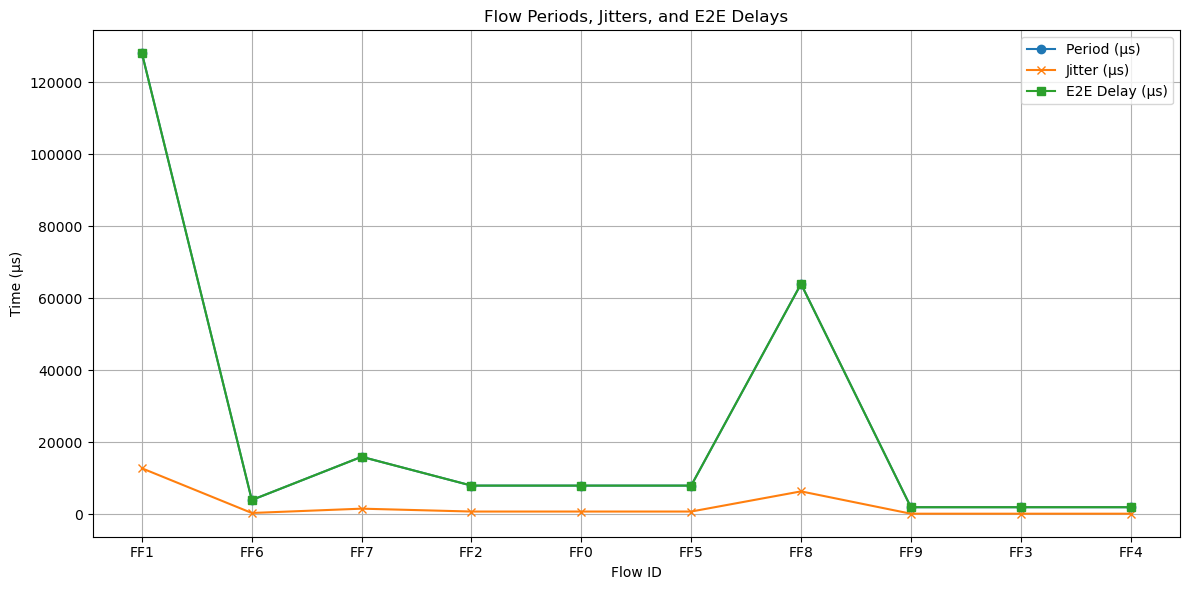

In [494]:
import matplotlib.pyplot as plt

# Prepare data
flow_ids = [flow.flow_id for flow in flow_data]
periods = [flow.period for flow in flow_data]
jitters = [flow.jitter for flow in flow_data]
delays = [getattr(flow, "e2e_delay", 0) for flow in flow_data]

# Create index for x-axis
x = list(range(len(flow_ids)))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(x, periods, label="Period (μs)", marker='o')
plt.plot(x, jitters, label="Jitter (μs)", marker='x')
plt.plot(x, delays, label="E2E Delay (μs)", marker='s')

# Labeling
plt.xticks(x, [f"F{fid}" for fid in flow_ids])
plt.xlabel("Flow ID")
plt.ylabel("Time (μs)")
plt.title("Flow Periods, Jitters, and E2E Delays")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [486]:
import pandas as pd

In [488]:
env_instance = vec_env.envs[0]

# Extract flows from the environment
flow_data = env_instance.flows  
# Get scheduled operations (results from the trained PPO agent)
operations = env_instance.links_operations 

import pandas as pd

flow_ids = []
periods = []
jitters = []
delay_tolerances = []
e2e_delays = []

for flow in flow_data:
    flow_ids.append(flow.flow_id)
    periods.append(flow.period)
    jitters.append(flow.jitter)
    delay_tolerances.append(flow.period - flow.jitter)

    # Fix: use the recorded delay if available
    delay = getattr(flow, "e2e_delay", None)
    e2e_delays.append(delay)

# Create DataFrame
df = pd.DataFrame({
    "Flow ID": flow_ids,
    "Period": periods,
    "Jitter": jitters,
    "Delay Tolerance": delay_tolerances,
    "E2E Delay": e2e_delays
})
df["Exceeds Delay?"] = df["E2E Delay"] > df["Delay Tolerance"]

# Display the table
from IPython.display import display
display(df)


    

,Flow ID,Period,Jitter,Delay Tolerance,E2E Delay,Exceeds Delay?
0,F1,128000,12800,115200,128000,True
1,F6,4000,400,3600,4000,True
2,F7,16000,1600,14400,16000,True
3,F2,8000,800,7200,8000,True
4,F0,8000,800,7200,8000,True
5,F5,8000,800,7200,8000,True
6,F8,64000,6400,57600,64000,True
7,F9,2000,200,1800,2000,True
8,F3,2000,200,1800,2000,True
9,F4,2000,200,1800,2000,True


In [409]:
import numpy as np
from stable_baselines3 import PPO  # or A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from src.env.env import NetEnv
from src.network.net import generate_graph, generate_flows, Network

# --- Parameters ---
topo = "CEV"              # Topology
link_rate = 100           # Mbps
num_flows = 5             # New flow count for testing

# --- Create new graph and flows ---
graph = generate_graph(topo, link_rate)
flows = generate_flows(graph, num_flows)  # NEW set of 20 flows
network = Network(graph, flows)
env = NetEnv(network)

# --- Wrap in SB3-compatible env ---
vec_env = DummyVecEnv([lambda: env])

# --- Load trained model ---
model = PPO.load("out/my_trained_model")  
# --- Run test ---
obs = vec_env.reset()
done = False
env_instance = vec_env.envs[0]
actions_taken = []

print("=== Testing Agent on 20 Flows ===")
while not done:
    action, _ = model.predict(obs, deterministic=True)
    
    current_flow = env_instance.current_flow()
    current_link = env_instance.current_link()

    obs, reward, done, info = vec_env.step(action)

    actions_taken.append((current_flow.flow_id, current_link.link_id, int(action[0])))
    print(f"Flow {current_flow.flow_id}, Link {current_link.link_id}, "
          f"Action: {'Gating' if action[0] == 1 else 'No Gating'}, Reward: {reward[0]}")



=== Testing Agent on 20 Flows ===
Flow F0, Link ('SM2CB', 'SW52'), Action: Gating, Reward: 0.9921875
Flow F0, Link ('SW52', 'SW42'), Action: Gating, Reward: 0.9921875
Flow F0, Link ('SW42', 'SW32'), Action: No Gating, Reward: 0.9806249737739563
Flow F0, Link ('SW32', 'SW6'), Action: No Gating, Reward: 0.9806249737739563
Flow F0, Link ('SW6', 'SMRIU1'), Action: No Gating, Reward: 0.984624981880188
Flow F2, Link ('SBAND1', 'SW12'), Action: Gating, Reward: 0.9921875
Flow F2, Link ('SW12', 'SW21'), Action: Gating, Reward: 0.9921875
Flow F2, Link ('SW21', 'SW13'), Action: Gating, Reward: 0.9921875
Flow F2, Link ('SW13', 'MIMU2'), Action: Gating, Reward: 1.0081875324249268
Flow F3, Link ('DU4', 'SW14'), Action: Gating, Reward: 0.9921875
Flow F3, Link ('SW14', 'SW21'), Action: Gating, Reward: 0.9921875
Flow F3, Link ('SW21', 'SW13'), Action: Gating, Reward: 0.96875
Flow F3, Link ('SW13', 'StarTr2'), Action: Gating, Reward: 1.0281875133514404
Flow F1, Link ('SM1CB', 'SW51'), Action: Gating, Re

In [492]:
env_instance = vec_env.envs[0]

# Extract flows from the environment
flow_data = env_instance.flows  
# Get scheduled operations (results from the trained PPO agent)
operations = env_instance.links_operations 

import pandas as pd

flow_ids = []
periods = []
jitters = []
delay_tolerances = []
e2e_delays = []

for flow in flow_data:
    flow_ids.append(flow.flow_id)
    periods.append(flow.period)
    jitters.append(flow.jitter)
    delay_tolerances.append(flow.period - flow.jitter)

    # Fix: use the recorded delay if available
    delay = getattr(flow, "e2e_delay", None)
    e2e_delays.append(delay)

# Create DataFrame
df = pd.DataFrame({
    "Flow ID": flow_ids,
    "Period": periods,
    "Jitter": jitters,
    "Delay Tolerance": delay_tolerances,
    "E2E Delay": e2e_delays
})
df["Exceeds Delay?"] = df["E2E Delay"] > df["Delay Tolerance"]


from IPython.display import display
# --- Calculate Accumulated Latency ---
valid_delays = [d for d in e2e_delays if d is not None]
accumulated_latency = sum(valid_delays)

# --- Show the table ---
print(df)
print(f"\n🧮 Accumulated E2E Latency: {accumulated_latency:.2f} time units")

    

  Flow ID  Period  Jitter  Delay Tolerance  E2E Delay  Exceeds Delay?
0      F1  128000   12800           115200     128000            True
1      F6    4000     400             3600       4000            True
2      F7   16000    1600            14400      16000            True
3      F2    8000     800             7200       8000            True
4      F0    8000     800             7200       8000            True
5      F5    8000     800             7200       8000            True
6      F8   64000    6400            57600      64000            True
7      F9    2000     200             1800       2000            True
8      F3    2000     200             1800       2000            True
9      F4    2000     200             1800       2000            True

🧮 Accumulated E2E Latency: 242000.00 time units


A2C usecase

In [457]:
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from src.agent.encoder import FeaturesExtractor
from src.env.env import TrainingNetEnv
from src.network.net import FlowGenerator, generate_graph
import numpy as np
import os

# --- Hyperparameters ---
topo = "CEV"  # or "CUSTOM"
num_flows = 10
link_rate = 100
time_steps = 100_000
jitters = [[0.1, 0.2, 0.3]]
list_jitters = np.array(jitters)
OUT_DIR = "out"
MONITOR_DIR = os.path.join(OUT_DIR, "monitor")
os.makedirs(MONITOR_DIR, exist_ok=True)

# --- Create Environment ---
def make_env():
    graph = generate_graph(topo, link_rate)
    flow_generator = FlowGenerator(graph, jitters=jitters[0])
    env = TrainingNetEnv(graph, flow_generator, num_flows=num_flows)
    env = Monitor(env, MONITOR_DIR)
    return env

env = DummyVecEnv([make_env])

# --- Define Model ---
policy_kwargs = dict(
    features_extractor_class=FeaturesExtractor,
)

model = A2C(
    "MultiInputPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
)

# --- Train Model ---
model.learn(total_timesteps=time_steps)




INFO:src.env.env.15164:Start training with 2 flows.


Using cpu device


INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 3
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INF

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 14.1     |
|    ep_rew_mean        | 13.5     |
| time/                 |          |
|    fps                | 118      |
|    iterations         | 100      |
|    time_elapsed       | 4        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.682   |
|    explained_variance | 0.000179 |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -4.71    |
|    value_loss         | 52.3     |
------------------------------------


INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 6
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 7
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (

...

-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 40.7      |
|    ep_rew_mean        | 39.6      |
| time/                 |           |
|    fps                | 119       |
|    iterations         | 19800     |
|    time_elapsed       | 825       |
|    total_timesteps    | 99000     |
| train/                |           |
|    entropy_loss       | -1.27e-06 |
|    explained_variance | 0.329     |
|    learning_rate      | 0.0007    |
|    n_updates          | 19799     |
|    policy_loss        | -0        |
|    value_loss         | 0.000941  |
-------------------------------------


INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)


-------------------------------------
| rollout/              |           |
|    ep_len_mean        | 41        |
|    ep_rew_mean        | 40.1      |
| time/                 |           |
|    fps                | 119       |
|    iterations         | 19900     |
|    time_elapsed       | 830       |
|    total_timesteps    | 99500     |
| train/                |           |
|    entropy_loss       | -6.84e-12 |
|    explained_variance | -2.41     |
|    learning_rate      | 0.0007    |
|    n_updates          | 19899     |
|    policy_loss        | -0        |
|    value_loss         | 0.000108  |
-------------------------------------


INFO:src.env.env.15164:passed the job! (6)
INFO:src.env.env.15164:passed the job! (7)
INFO:src.env.env.15164:passed the job! (8)
INFO:src.env.env.15164:passed the job! (9)
INFO:src.env.env.15164:passed the job! (10)
INFO:src.env.env.15164:Great! The agent has already learnt how to solve the problem. Change the flows to train the agent. num_flows: 10
INFO:src.env.env.15164:passed the job! (1)
INFO:src.env.env.15164:passed the job! (2)
INFO:src.env.env.15164:passed the job! (3)
INFO:src.env.env.15164:passed the job! (4)
INFO:src.env.env.15164:passed the job! (5)
INFO:src.env.env.15164:end of episode, reason: [ErrorType.JitterExceed: jitter constraint unsatisfied. 387 > 200]	Scheduled flows: 9


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 41.9     |
|    ep_rew_mean        | 41       |
| time/                 |          |
|    fps                | 119      |
|    iterations         | 20000    |
|    time_elapsed       | 834      |
|    total_timesteps    | 100000   |
| train/                |          |
|    entropy_loss       | -2.3e-09 |
|    explained_variance | -19.1    |
|    learning_rate      | 0.0007   |
|    n_updates          | 19999    |
|    policy_loss        | -0       |
|    value_loss         | 48.6     |
------------------------------------


In [460]:
model.save("out/A2C_new_model")


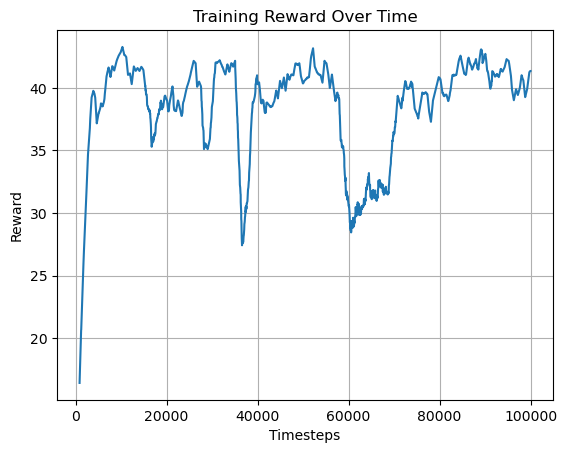

In [462]:
import matplotlib.pyplot as plt
from stable_baselines3.common.results_plotter import load_results, ts2xy

def moving_average(values, window):
    weights = np.repeat(1.0, window) / window
    return np.convolve(values, weights, 'valid')

def plot_results(log_folder, title="Learning Curve"):
    x, y = ts2xy(load_results(log_folder), "timesteps")
    if len(y) < 50:
        print("⚠️ Not enough data to smooth. Showing raw rewards.")
        plt.plot(x, y)
    else:
        y_smooth = moving_average(y, window=50)
        x = x[len(x) - len(y_smooth):]
        plt.plot(x, y_smooth)

    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_results(MONITOR_DIR, title="Training Reward Over Time")


In [464]:
import numpy as np
from stable_baselines3 import PPO  # or A2C
from stable_baselines3.common.vec_env import DummyVecEnv
from src.env.env import NetEnv
from src.network.net import generate_graph, generate_flows, Network

# --- Parameters ---
topo = "CEV"              # Topology
link_rate = 100           # Mbps
num_flows = 10            # New flow count for testing

# --- Create new graph and flows ---
graph = generate_graph(topo, link_rate)
flows = generate_flows(graph, num_flows)  # NEW set of 20 flows
network = Network(graph, flows)
env = NetEnv(network)

# --- Wrap in SB3-compatible env ---
vec_env = DummyVecEnv([lambda: env])

# --- Load trained model ---
model = A2C.load("out/A2C_new_model")  
# --- Run test ---
obs = vec_env.reset()
done = False
env_instance = vec_env.envs[0]
actions_taken = []

print("=== Testing Agent on10 Flows ===")
while not done:
    action, _ = model.predict(obs, deterministic=True)
    
    current_flow = env_instance.current_flow()
    current_link = env_instance.current_link()

    obs, reward, done, info = vec_env.step(action)

    actions_taken.append((current_flow.flow_id, current_link.link_id, int(action[0])))
    print(f"Flow {current_flow.flow_id}, Link {current_link.link_id}, "
          f"Action: {'Gating' if action[0] == 1 else 'No Gating'}, Reward: {reward[0]}")



=== Testing Agent on10 Flows ===
Flow F6, Link ('FCM1', 'SW31'), Action: Gating, Reward: 0.9921875
Flow F6, Link ('SW31', 'RCM1'), Action: Gating, Reward: 0.9931874871253967
Flow F5, Link ('MIMU3', 'SW13'), Action: Gating, Reward: 0.9921875
Flow F5, Link ('SW13', 'MIMU1'), Action: Gating, Reward: 0.9961875081062317
Flow F2, Link ('FCM2', 'SW32'), Action: Gating, Reward: 0.9921875
Flow F2, Link ('SW32', 'SW6'), Action: Gating, Reward: 0.9921875
Flow F2, Link ('SW6', 'SMRIU2'), Action: Gating, Reward: 1.0011874437332153
Flow F7, Link ('SM1CA', 'SW51'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW51', 'SW41'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW41', 'SW31'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW31', 'SW21'), Action: Gating, Reward: 0.9921875
Flow F7, Link ('SW21', 'SW13'), Action: No Gating, Reward: 0.9225000143051147
Flow F7, Link ('SW13', 'MIMU3'), Action: No Gating, Reward: 0.9384999871253967
Flow F4, Link ('MIMU2', 'SW13'), Action: No Gating, Re

In [512]:
env_instance = vec_env.envs[0]

# Extract flows from the environment
flow_data = env_instance.flows  
# Get scheduled operations (results from the trained PPO agent)
operations = env_instance.links_operations 

import pandas as pd

flow_ids = []
periods = []
jitters = []
delay_tolerances = []
e2e_delays = []

for flow in flow_data:
    flow_ids.append(flow.flow_id)
    periods.append(flow.period)
    jitters.append(flow.jitter)
    delay_tolerances.append(flow.period - flow.jitter)
    delay = getattr(flow, "e2e_delay", None)
    e2e_delays.append(delay)




df = pd.DataFrame({
    "Flow ID": flow_ids,
    "Period": periods,
    "Jitter": jitters,
    "Delay Tolerance": delay_tolerances,
    "E2E Delay": e2e_delays,
})
df["Exceeds Delay?"] = df["E2E Delay"] > df["Delay Tolerance"]

import pandas as pd

import pandas as pd

scheduled_flows = []
for flow_id, _, _ in actions_taken:
    if flow_id not in scheduled_flows:
        scheduled_flows.append(flow_id)

scheduled_order = {flow_id: idx + 1 for idx, flow_id in enumerate(scheduled_flows)}


path_lengths = {flow.flow_id: len(flow.path) for flow in flow_data}


df["Scheduled Order"] = df["Flow ID"].map(scheduled_order)
df["Path Length"] = df["Flow ID"].map(path_lengths)


print(df)


    

  Flow ID  Period  Jitter  Delay Tolerance  E2E Delay  Exceeds Delay?  \
0      F1  128000   12800           115200     128000            True   
1      F6    4000     400             3600       4000            True   
2      F7   16000    1600            14400      16000            True   
3      F2    8000     800             7200       8000            True   
4      F0    8000     800             7200       8000            True   
5      F5    8000     800             7200       8000            True   
6      F8   64000    6400            57600      64000            True   
7      F9    2000     200             1800       2000            True   
8      F3    2000     200             1800       2000            True   
9      F4    2000     200             1800       2000            True   

   Scheduled Order  Path Length  
0                2            5  
1                6            4  
2                1            5  
3                9            3  
4                5        

In [453]:
scheduled_flows = []

done = False
obs = vec_env.reset()
env_instance = vec_env.envs[0]

while not done:
    flow = env_instance.current_flow()
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)

    # Add only once per flow
    if flow.flow_id not in scheduled_flows:
        scheduled_flows.append(flow.flow_id)

print("Order of scheduled flows:")
print(scheduled_flows)


Order of scheduled flows:
['F6', 'F8', 'F5', 'F1', 'F4', 'F3', 'F2', 'F7', 'F0', 'F9']


TABU Scheduler

In [339]:
from src.app import no_wait_tabu_scheduler
from src.network.net import generate_graph, generate_flows, Network
from src.app.no_wait_tabu_scheduler import NoWaitTabuScheduler


In [341]:
from src.app.no_wait_tabu_scheduler import TimeTablingScheduler

In [329]:
topo = "CEV"  # or your custom topo
num_flows = 10
link_rate = 100

graph = generate_graph(topo, link_rate)
flows = generate_flows(graph, num_flows)
network = Network(graph, flows)


In [345]:
scheduler = NoWaitTabuScheduler(network, stop_upon_valid=True)
is_scheduled = scheduler.schedule()


INFO:root:Heuristic: InitialHeuristic.SumAsc
INFO:root:Sequencing alg...
INFO:root:Start iterate.
INFO:root:Success to schedule.


In [333]:
if is_scheduled:
    print("✅ Tabu Scheduler succeeded.")
    schedule_res = scheduler.get_res()

    for link, operations in schedule_res.items():
        print(f"Link {link.link_id}:")
        for flow, op in operations:
            print(f"  Flow F{flow.flow_id} → Operation: {op}")
else:
    print("❌ Tabu Scheduler failed to schedule all flows.")


✅ Tabu Scheduler succeeded.
Link ('SBAND2', 'SW12'):
  Flow FF1 → Operation: Operation(0, 0, 76)(0, 0)
Link ('SW12', 'SW21'):
  Flow FF1 → Operation: Operation(78, 83, 159)(78, 83)
Link ('SW21', 'SW31'):
  Flow FF1 → Operation: Operation(161, 166, 242)(161, 166)
Link ('SW31', 'SW41'):
  Flow FF1 → Operation: Operation(244, 249, 325)(244, 249)
Link ('SW41', 'CM1CA'):
  Flow FF1 → Operation: Operation(327, 332, 408)(327, 332)
Link ('CM1CA', 'SW41'):
  Flow FF6 → Operation: Operation(0, 0, 27)(0, 0)
  Flow FF0 → Operation: Operation(102, 102, 174)(102, 102)
Link ('SW41', 'SW31'):
  Flow FF6 → Operation: Operation(29, 34, 61)(29, 34)
  Flow FF9 → Operation: Operation(117, 122, 176)(117, 122)
  Flow FF0 → Operation: Operation(176, 181, 253)(176, 181)
Link ('SW31', 'SW21'):
  Flow FF6 → Operation: Operation(63, 68, 95)(63, 68)
  Flow FF9 → Operation: Operation(178, 183, 237)(178, 183)
  Flow FF2 → Operation: Operation(237, 242, 334)(237, 242)
Link ('SW21', 'SW11'):
  Flow FF6 → Operation: Op

In [516]:
graph = generate_graph(topo="CEV", link_rate=100)

# Print all nodes
print("Nodes in topology:")
for node in graph.nodes(data=True):
    print(node)

# Print all links (edges)
print("\nLinks in topology:")
for edge in graph.edges(data=True):
    print(edge)
num_switches = sum(1 for _, attr in graph.nodes(data=True) if attr.get("node_type") == "SW")
num_end_systems = sum(1 for _, attr in graph.nodes(data=True) if attr.get("node_type") == "ES")

print(f"Number of switches (SW): {num_switches}")
print(f"Number of end systems (ES): {num_end_systems}")


Nodes in topology:
('DU1', {'node_type': 'ES'})
('SW11', {'node_type': 'SW'})
('DU2', {'node_type': 'ES'})
('DU3', {'node_type': 'ES'})
('CMRIU1', {'node_type': 'ES'})
('SW21', {'node_type': 'SW'})
('FCM1', {'node_type': 'ES'})
('SW31', {'node_type': 'SW'})
('LCM1', {'node_type': 'ES'})
('RCM1', {'node_type': 'ES'})
('CM1CA', {'node_type': 'ES'})
('SW41', {'node_type': 'SW'})
('CM1CB', {'node_type': 'ES'})
('SM1CA', {'node_type': 'ES'})
('SW51', {'node_type': 'SW'})
('SM1CB', {'node_type': 'ES'})
('SMRIU1', {'node_type': 'ES'})
('SW6', {'node_type': 'SW'})
('SMRIU2', {'node_type': 'ES'})
('SM2CB', {'node_type': 'ES'})
('SW52', {'node_type': 'SW'})
('SM2CA', {'node_type': 'ES'})
('CM2CB', {'node_type': 'ES'})
('SW42', {'node_type': 'SW'})
('CM2CA', {'node_type': 'ES'})
('RCM2', {'node_type': 'ES'})
('SW32', {'node_type': 'SW'})
('LCM2', {'node_type': 'ES'})
('FCM2', {'node_type': 'ES'})
('CMRIU2', {'node_type': 'ES'})
('SW22', {'node_type': 'SW'})
('BFCU', {'node_type': 'ES'})
('DU5', {